# Single value deconvolution of replication timing

May 6, 2024

Goal: Can we deconvolve a single value (position in S/G2M) where replication occurs for each 10k window?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:01:57.591
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:05.299


In [3]:
mnase_analysis_rep1.compute_replication_timing()
mnase_analysis_rep2.compute_replication_timing()

In [4]:
from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver

# todo: add replication 2
solver = StepReplicationChromatinDeconvolveSolver(mnase_analysis_rep1, mnase_analysis_rep2)

In [161]:
solver.set_chrom(10)

In [162]:
from src.timer import Timer

"""
Deconvolve all of the bins for a chromosome one at a time. The
deconvolved problem runs faster by running the solver independently
rather than all together. Possibly because the solver doesn't recognize
the independence of the different problems..

todo: is this true for the chromatin gene deconvolutions as well?
"""
timer = Timer()

n = len(solver.chr_genes)

all_fs = None
for bin_idx in np.arange(n):
    solver.select_bins([bin_idx])
    solver.solve(verbose=False)
    if bin_idx % 10 == 0:
        timer.print_time(f"{bin_idx}/{n}")
    current_f = solver.f
    if bin_idx == 0:
        all_fs = np.zeros((n, current_f.shape[0]))
    all_fs[bin_idx] = current_f.flatten()
all_fs = all_fs.T

0/340 - 00:00:00.667
10/340 - 00:00:07.926
20/340 - 00:00:15.463
30/340 - 00:00:22.859
40/340 - 00:00:30.774
50/340 - 00:00:39.331
60/340 - 00:00:46.708
70/340 - 00:00:54.365
80/340 - 00:01:01.908
90/340 - 00:01:09.909
100/340 - 00:01:18.587
110/340 - 00:01:26.325
120/340 - 00:01:33.857
130/340 - 00:01:41.597
140/340 - 00:01:48.877
150/340 - 00:01:56.202
160/340 - 00:02:04.120
170/340 - 00:02:12.654
180/340 - 00:02:20.385
190/340 - 00:02:28.885
200/340 - 00:02:36.898
210/340 - 00:02:44.863
220/340 - 00:02:52.866
230/340 - 00:03:00.458
240/340 - 00:03:07.614
250/340 - 00:03:15.764
260/340 - 00:03:23.907
270/340 - 00:03:30.453
280/340 - 00:03:37.970
290/340 - 00:03:45.049
300/340 - 00:03:51.683
310/340 - 00:03:58.506
320/340 - 00:04:05.319
330/340 - 00:04:12.344


In [202]:
from src.sgd import get_chromosome_length

Text(0.5, 1.0, 'Chromosome 10, deconvolved profile')

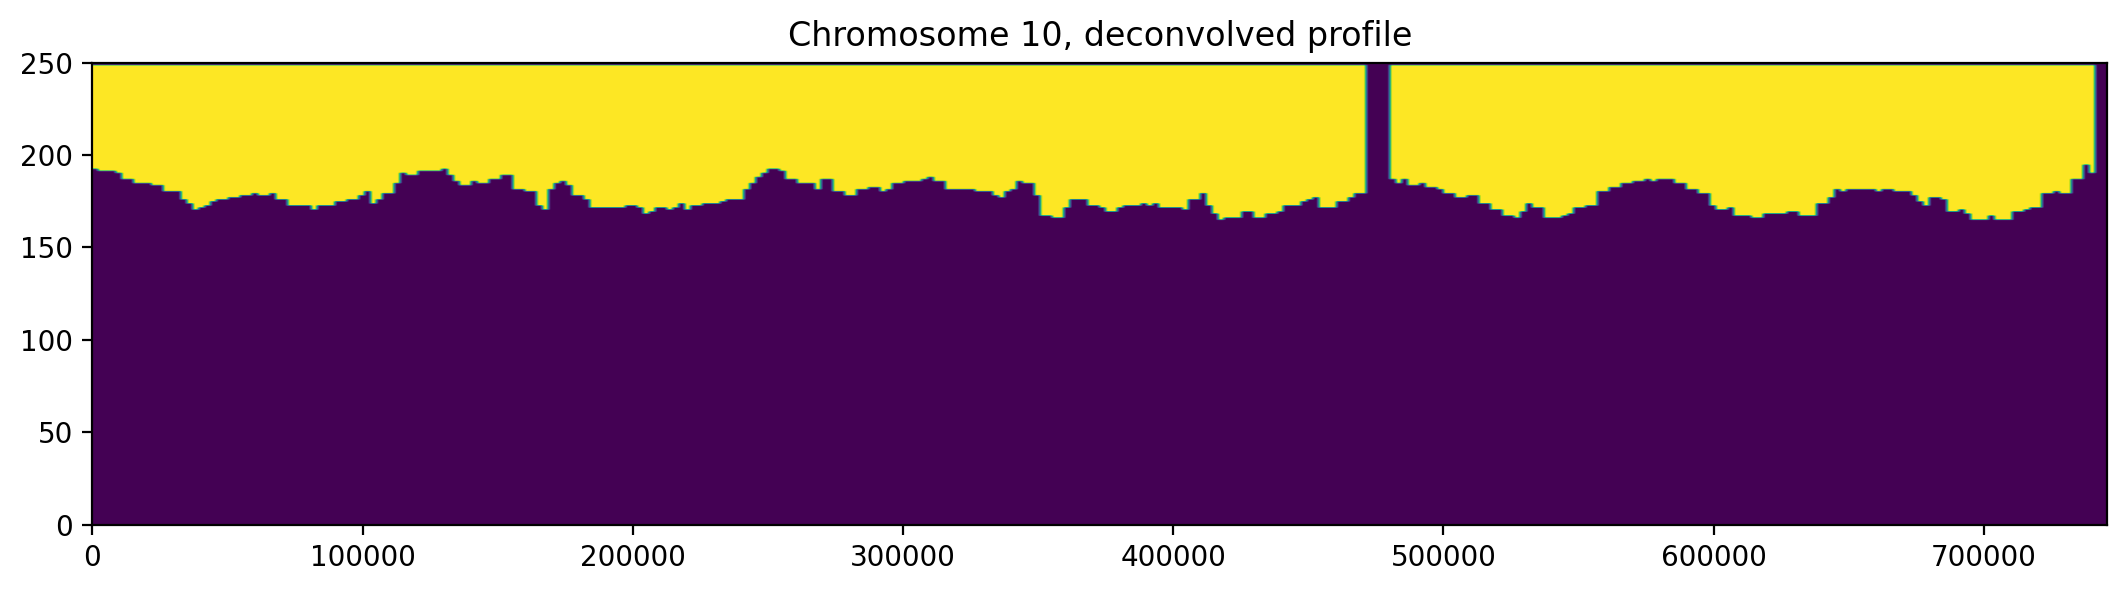

In [204]:
chrom_len = get_chromosome_length(solver.chrom)
plt.figure(figsize=(13, 3))
plt.imshow(all_fs, origin='lower', aspect='auto', extent=[0, chrom_len, 
                                                         0, 250])
plt.title(f"Chromosome {solver.chrom}, deconvolved profile")

In [164]:
solver.compute_replication_timing(all_fs)

(20.0, 0.0)

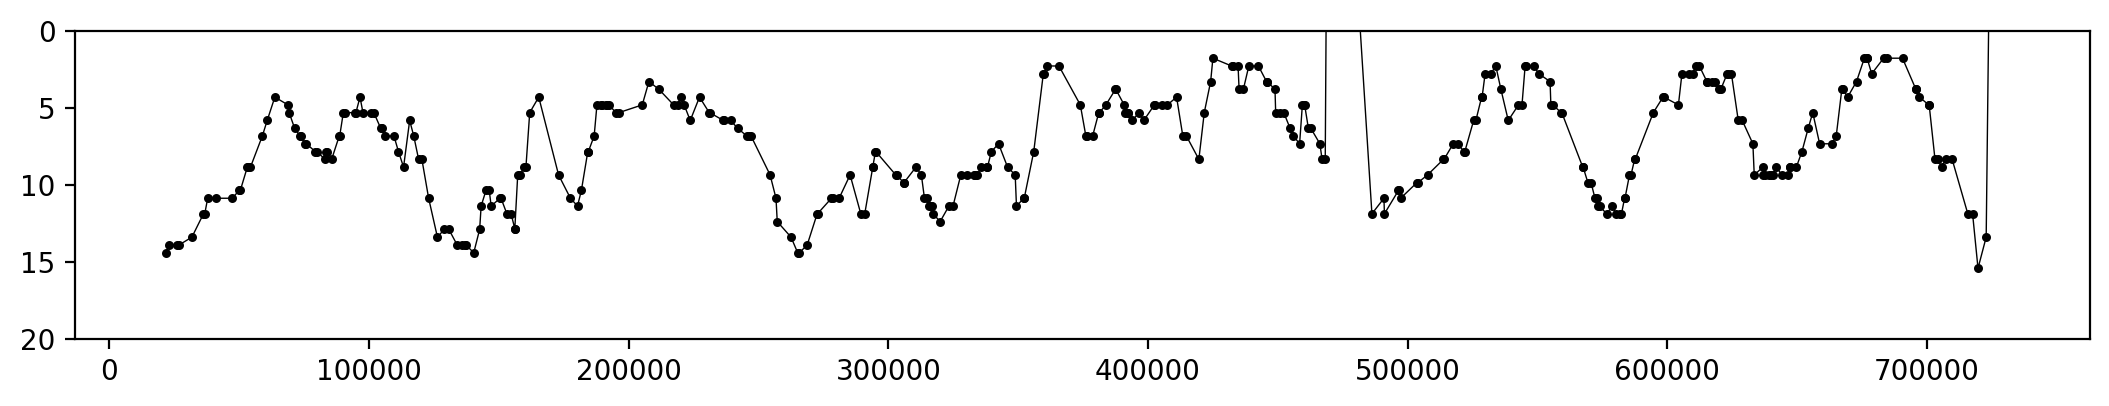

In [206]:
plt.figure(figsize=(13, 2))
plt.plot(solver.chr_genes.TSS, solver.replication_timing_df.replication_time, 
         lw=0.5, c='black')
plt.scatter(solver.chr_genes.TSS, solver.replication_timing_df.replication_time,
            s=5, c='black')

#plt.plot(solver.replication_timing_df.replication_time, lw=0.5, c='black')
#plt.axvline(243)
#plt.axvline(79)
plt.ylim(20, 0)


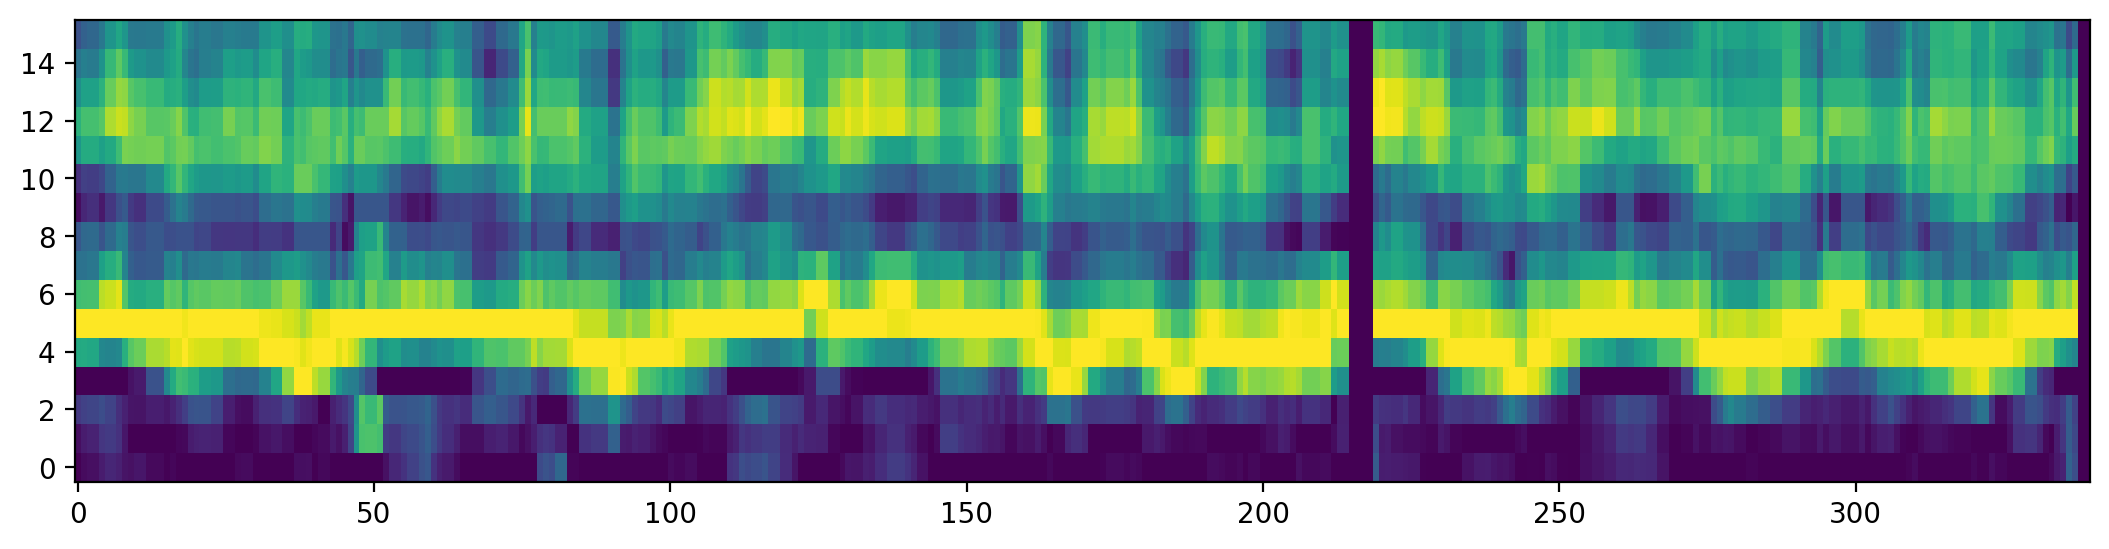

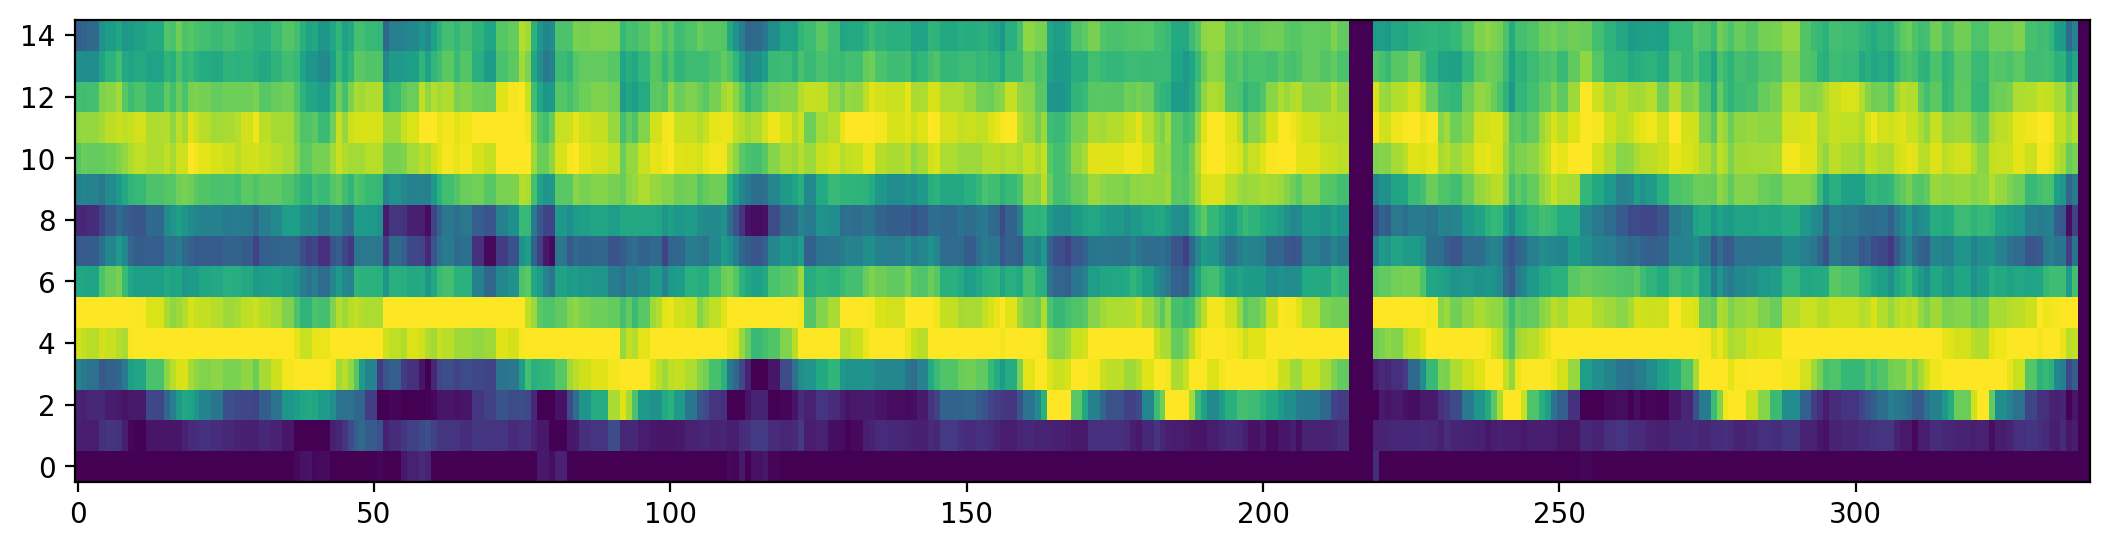

In [189]:
plt.figure(figsize=(13, 3))
plt.imshow(solver.adjusted_curves_1.T, origin='lower', aspect='auto', vmin=0, vmax=1)
#plt.axvline(243, c='white', lw=2, ls='dotted', alpha=0.5)
#plt.axvline(79, c='white', lw=2, ls='dotted', alpha=0.5)

plt.figure(figsize=(13, 3))
plt.imshow(solver.adjusted_curves_2.T, origin='lower', aspect='auto', vmin=0, vmax=1)
#plt.axvline(243, c='white', lw=2, ls='dotted', alpha=0.5)
#plt.axvline(79, c='white', lw=2, ls='dotted', alpha=0.5)

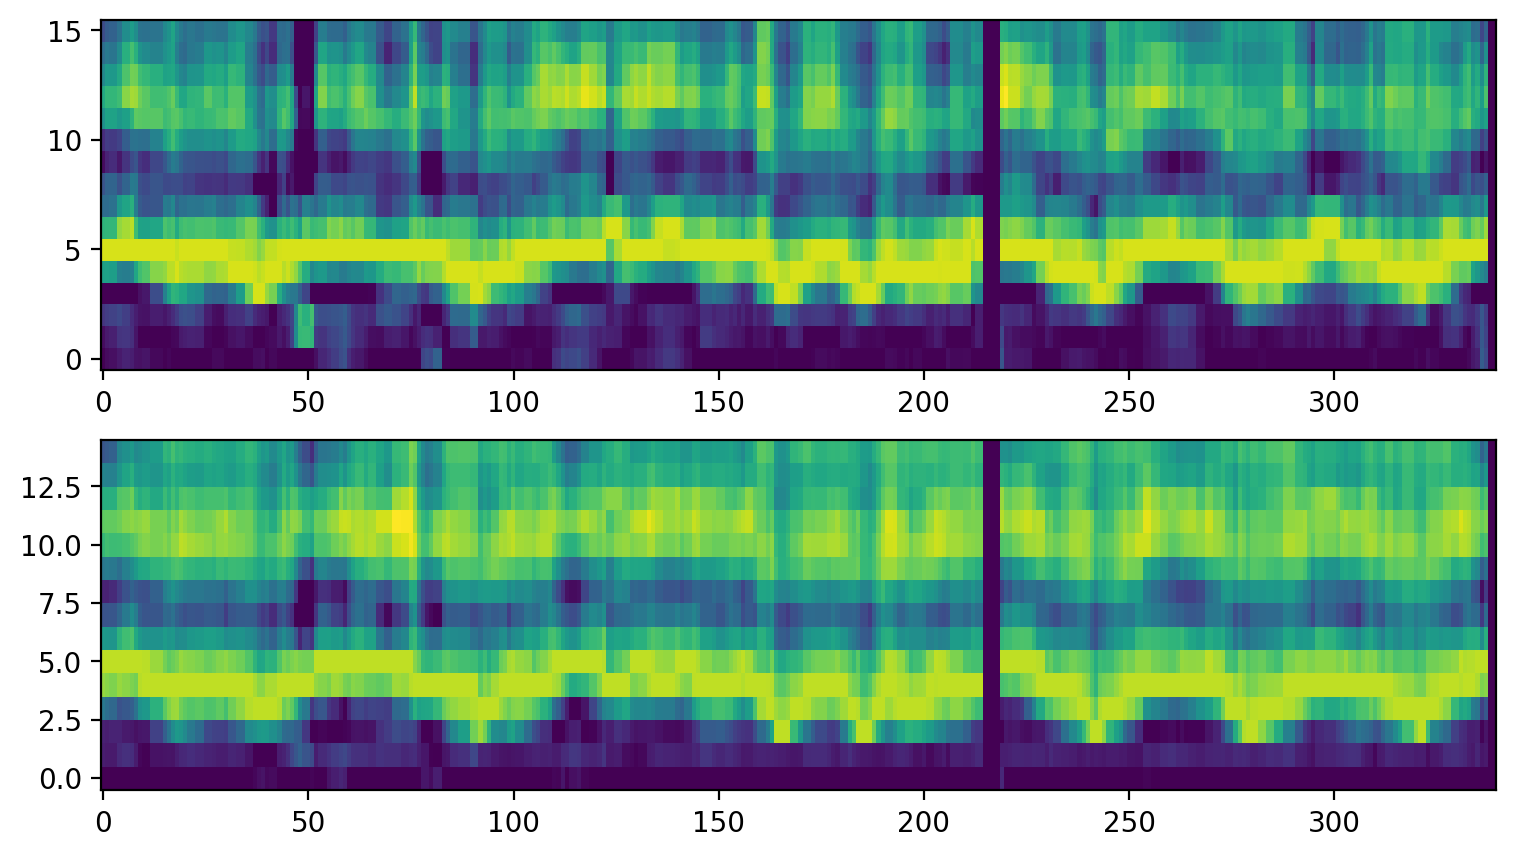

In [168]:
plt.figure(figsize=(9, 5))
plt.subplot(2, 1, 1)
plt.imshow(solver.chr_bin_curves1.T, origin='lower', aspect='auto', vmin=0)
plt.subplot(2, 1, 2)
plt.imshow(solver.chr_bin_curves2.T, origin='lower', aspect='auto', vmin=0)

In [29]:
# Strategy:

# Record the genes/bins that exhibit this phenomena:
"""
The 10k bin the gene resides in are broken down into the first cell cycle A. 
And following cell cycle B.

For most bins, the min and max of the occupancies in A, are absolute as this is the period
in which the cells are the most synchronized across the time course.

However, there are some genes in which this is violated. A handful of which have min's in
B lower than A. 

Record which genes these are, and perform a correction. We are using existing replication
profiles as ground truth.
"""


"\nThe 10k bin the gene resides in are broken down into the first cell cycle A. \nAnd following cell cycle B.\n\nFor most bins, the min and max of the occupancies in A, are absolute as this is the period\nin which the cells are the most synchronized across the time course.\n\nHowever, there are some genes in which this is violated. A handful of which have min's in\nB lower than A. \n\nRecord which genes these are, and perform a correction. We are using existing replication\nprofiles as ground truth.\n"

In [199]:
# Get the first cell cycle end, to partition the raw data
# into two parts
recovery_len, first_s_start, first_s_end, first_cc_end = \
    solver.config1.get_key_timepoints_in_raw()

from src.stepwise_replication_solver import load_copy_num

bin_dat, normalized_bin_dat, copy_scaling, (first_half, second_half),\
    (normalized_first, normalized_second) = \
    solver.normalize_raw_bin_by_half_copy_scaling(243, 1)


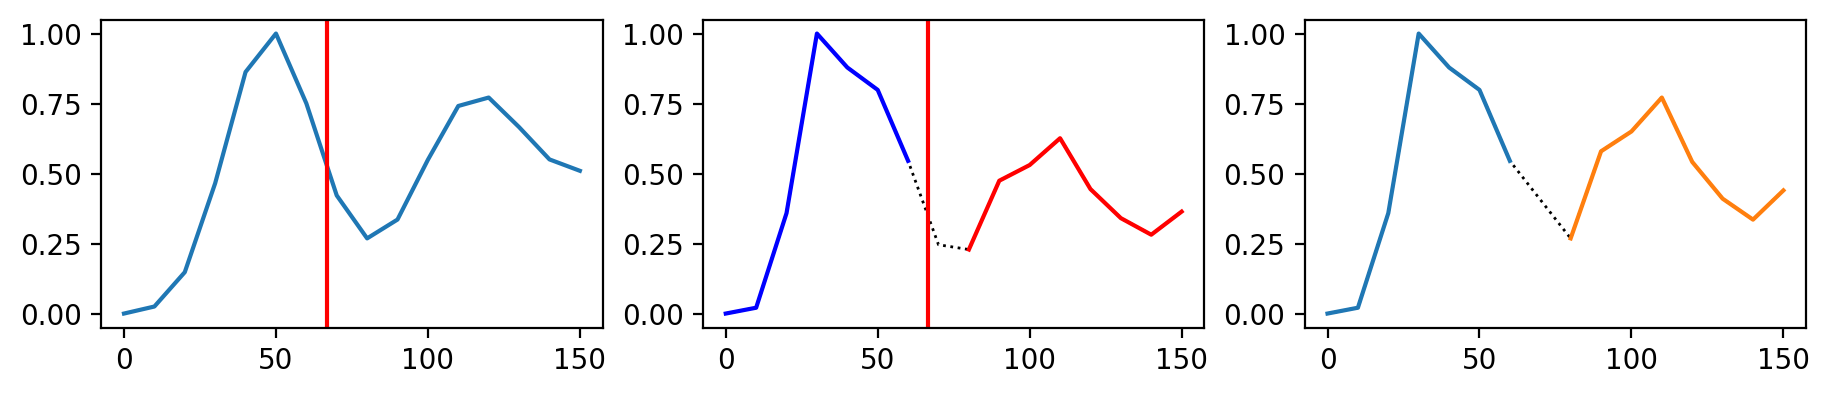

In [200]:
plt.figure(figsize=(11, 2))

plt.subplot(1, 3, 1)
plt.plot(copy_scaling)
plt.axvline(first_cc_end, c='red')

plt.subplot(1, 3, 2)
plt.plot(bin_dat, lw=1, ls='dotted', c='black')
plt.axvline(first_cc_end, c='red')

plt.plot(first_half, c='blue')
plt.plot(second_half, c='red')
ax = plt.subplot(1, 3, 3)

plt.plot(normalized_bin_dat, c='black', lw=1, ls='dotted')
plt.plot(first_half.index, normalized_first)
plt.plot(second_half.index, normalized_second)

In [192]:
solver.adjust_bins_for_anomalous_min_maxes()

In [197]:
gs = solver.chr_genes.copy()
gs['gene_idx'] = np.arange(len(gs))

In [198]:
pd.DataFrame(solver.adjusted_genes).join(gs['gene_idx'])

,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end,gene_idx
YJL173C,RFA3,10,gene,96161,96529,-,Verified,368,96561,96085.0,False,96561.0,96861.0,96061.0,96561.0,37
YJL172W,CPS1,10,gene,97737,99467,+,Verified,1730,97699,99609.0,False,97399.0,97699.0,97699.0,98199.0,38
YJL171C,YJL171C,10,gene,99704,100894,-,Verified,1190,100933,99505.0,False,100933.0,101233.0,100433.0,100933.0,39
YJL170C,ASG7,10,gene,101150,101779,-,Verified,629,101888,101124.0,False,101888.0,102188.0,101388.0,101888.0,40
YJL168C,SET2,10,gene,102227,104428,-,Verified,2201,104522,102032.0,False,104522.0,104822.0,104022.0,104522.0,41
YJL167W,ERG20,10,gene,105014,106072,+,Verified,1058,104959,106166.0,False,104659.0,104959.0,104959.0,105459.0,42
YJL162C,JJJ2,10,gene,113878,115629,-,Verified,1751,115686,113713.0,False,115686.0,115986.0,115186.0,115686.0,47
YJL161W,FMP33,10,gene,117245,117787,+,Uncharacterized,542,117257,117942.0,False,116957.0,117257.0,117257.0,117757.0,48
YJL160C,YJL160C,10,gene,117962,118825,-,Uncharacterized,863,119133,117844.0,False,119133.0,119433.0,118633.0,119133.0,49
YJL159W,HSP150,10,gene,120449,121690,+,Verified,1241,120396,121993.0,False,120096.0,120396.0,120396.0,120896.0,50
